In [30]:
!pip install pandas matplotlib seaborn wordcloud

In [31]:
import pandas as pd
import json

with open("/kaggle/input/datasets/adityamaj20051004/dataset2/watch-history.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print(len(data))

<class 'list'>
4500


In [32]:
df = pd.DataFrame(data)

df.head()

,header,title,titleUrl,subtitles,time,products,activityControls
0,YouTube,Watched মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধা...,https://www.youtube.com/watch?v=__9pXNTYb3E,"[{'name': 'Aaj Tak Bangla', 'url': 'https://ww...",2026-05-22T07:19:09.868Z,[YouTube],[YouTube watch history]
1,YouTube,Watched 😭BLURRED COPIES+SITE NOT WORKING 💔#cbs...,https://www.youtube.com/watch?v=3kptOVnxEsY,"[{'name': 'Shree', 'url': 'https://www.youtube...",2026-05-22T07:18:28.031Z,[YouTube],[YouTube watch history]
2,YouTube,Watched Bengal Makes Vande Mataram Mandatory I...,https://www.youtube.com/watch?v=WVWICiQ_paI,"[{'name': 'India Today', 'url': 'https://www.y...",2026-05-22T07:17:45.175Z,[YouTube],[YouTube watch history]
3,YouTube,Watched Cockroach Janta Party Anthem song CJP2026,https://www.youtube.com/watch?v=Wvqe-lIYLOE,"[{'name': 'Pawan Meghwanshi official ', 'url':...",2026-05-22T07:17:08.216Z,[YouTube],[YouTube watch history]
4,YouTube,Watched It's time to set Bangladesh Fielding🤣🚩...,https://www.youtube.com/watch?v=M6pTkLSnSJ8,"[{'name': 'Bharat Matters ', 'url': 'https://w...",2026-05-22T07:16:46.124Z,[YouTube],[YouTube watch history]


In [33]:
df["channel"] = df["subtitles"].apply(
    lambda x: x[0]["name"] if isinstance(x, list) and len(x) > 0 else None
)

df["time"] = pd.to_datetime(
    df["time"],
    format="mixed"
)

df["title_clean"] = df["title"].str.replace(
    "Watched ",
    "",
    regex=False
)

df = df[[
    "title_clean",
    "channel",
    "time",
    "titleUrl"
]]

df.head()

,title_clean,channel,time,titleUrl
0,মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধান্ত মানব...,Aaj Tak Bangla,2026-05-22 07:19:09.868000+00:00,https://www.youtube.com/watch?v=__9pXNTYb3E
1,😭BLURRED COPIES+SITE NOT WORKING 💔#cbse #cbsec...,Shree,2026-05-22 07:18:28.031000+00:00,https://www.youtube.com/watch?v=3kptOVnxEsY
2,Bengal Makes Vande Mataram Mandatory In School...,India Today,2026-05-22 07:17:45.175000+00:00,https://www.youtube.com/watch?v=WVWICiQ_paI
3,Cockroach Janta Party Anthem song CJP2026,Pawan Meghwanshi official,2026-05-22 07:17:08.216000+00:00,https://www.youtube.com/watch?v=Wvqe-lIYLOE
4,It's time to set Bangladesh Fielding🤣🚩 #suvend...,Bharat Matters,2026-05-22 07:16:46.124000+00:00,https://www.youtube.com/watch?v=M6pTkLSnSJ8


In [34]:
print("Total videos watched:", len(df))

Total videos watched: 4500


In [35]:
top_channels = df["channel"].value_counts().head(10)

print(top_channels)

channel
ABP ANANDA         121
TV9 Bangla         104
Aaj Tak Bangla      75
News18 Bangla       71
Zee 24 Ghanta       71
Republic Bangla     68
Narendra Modi       64
StudyIQ IAS         57
The Lallantop       56
Dainik Bhaskar      40
Name: count, dtype: int64


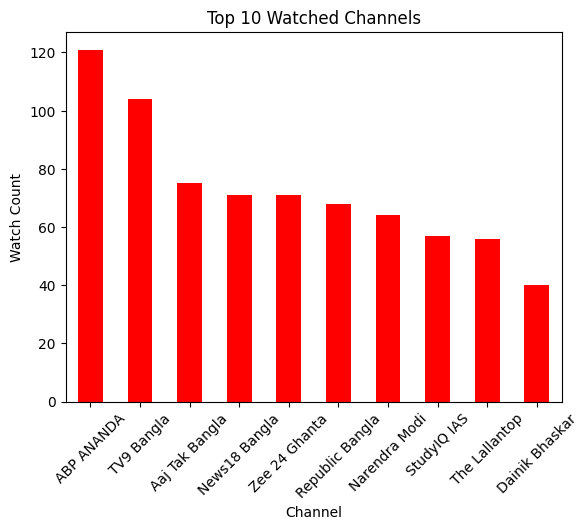

In [36]:
import matplotlib.pyplot as plt

top_channels.plot(kind="bar",color="red")

plt.title("Top 10 Watched Channels")
plt.xlabel("Channel")
plt.ylabel("Watch Count")

plt.xticks(rotation=45)
plt.show()

In [37]:
print(df["time"].dtype)

datetime64[ns, UTC]


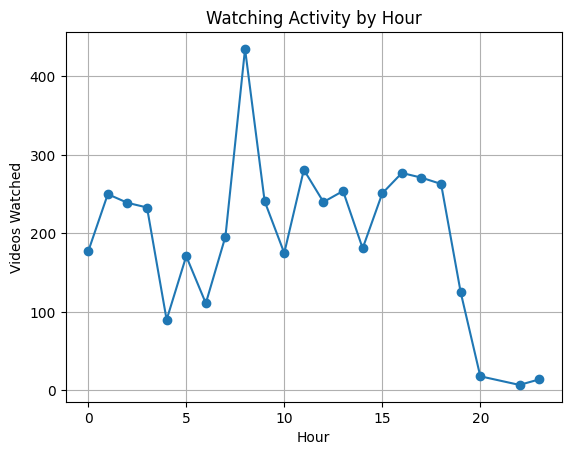

In [38]:
df["hour"] = df["time"].dt.hour

hourly = df["hour"].value_counts().sort_index()

hourly.plot(kind="line", marker="o")

plt.title("Watching Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Videos Watched")

plt.grid(True)
plt.show()

In [39]:
df.head()

,title_clean,channel,time,titleUrl,hour
0,মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধান্ত মানব...,Aaj Tak Bangla,2026-05-22 07:19:09.868000+00:00,https://www.youtube.com/watch?v=__9pXNTYb3E,7
1,😭BLURRED COPIES+SITE NOT WORKING 💔#cbse #cbsec...,Shree,2026-05-22 07:18:28.031000+00:00,https://www.youtube.com/watch?v=3kptOVnxEsY,7
2,Bengal Makes Vande Mataram Mandatory In School...,India Today,2026-05-22 07:17:45.175000+00:00,https://www.youtube.com/watch?v=WVWICiQ_paI,7
3,Cockroach Janta Party Anthem song CJP2026,Pawan Meghwanshi official,2026-05-22 07:17:08.216000+00:00,https://www.youtube.com/watch?v=Wvqe-lIYLOE,7
4,It's time to set Bangladesh Fielding🤣🚩 #suvend...,Bharat Matters,2026-05-22 07:16:46.124000+00:00,https://www.youtube.com/watch?v=M6pTkLSnSJ8,7


In [40]:
df["hour"] = df["time"].dt.hour

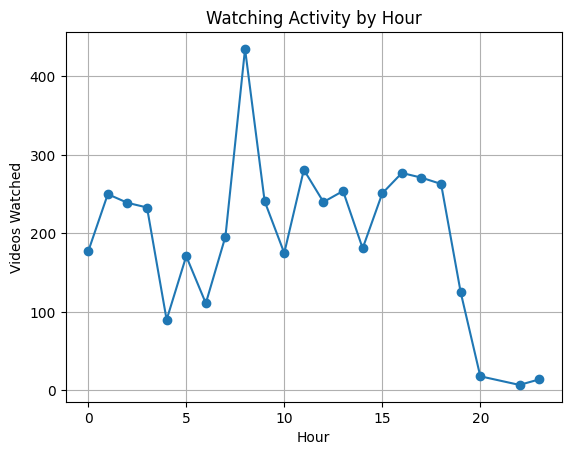

In [41]:
hourly = df["hour"].value_counts().sort_index()

hourly.plot(kind="line", marker="o")

plt.title("Watching Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Videos Watched")

plt.grid(True)
plt.show()

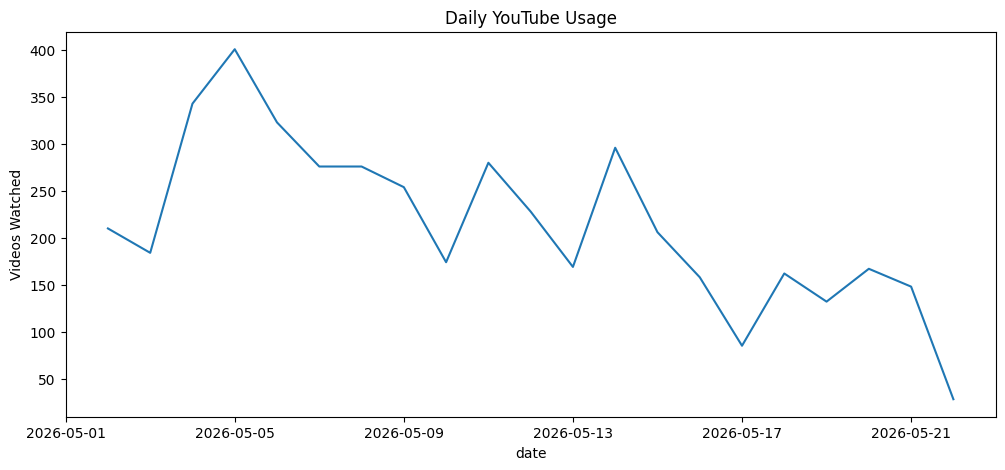

In [42]:
df["date"] = df["time"].dt.date

daily = df.groupby("date").size()

daily.plot(figsize=(12,5))

plt.title("Daily YouTube Usage")
plt.ylabel("Videos Watched")

plt.show()

In [43]:
top_channels = df["channel"].value_counts().head(10)

print(top_channels)

channel
ABP ANANDA         121
TV9 Bangla         104
Aaj Tak Bangla      75
News18 Bangla       71
Zee 24 Ghanta       71
Republic Bangla     68
Narendra Modi       64
StudyIQ IAS         57
The Lallantop       56
Dainik Bhaskar      40
Name: count, dtype: int64


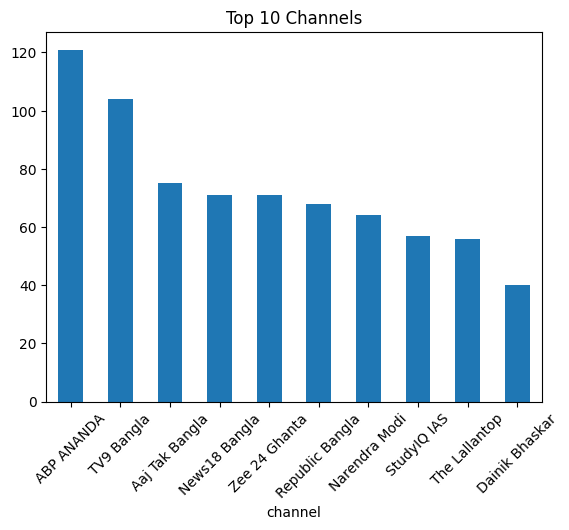

In [44]:
top_channels.plot(kind="bar")

plt.title("Top 10 Channels")
plt.xticks(rotation=45)

plt.show()

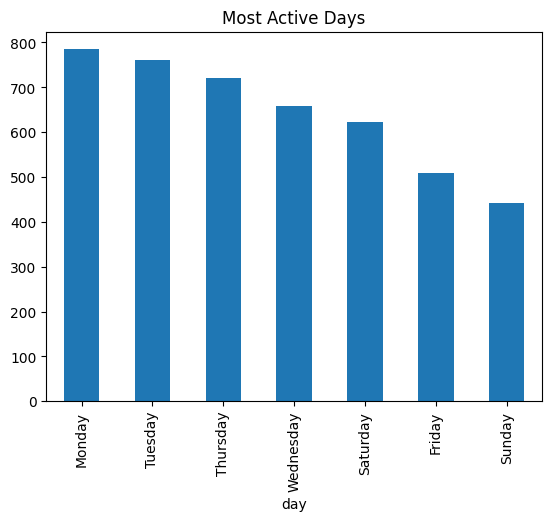

In [45]:
df["day"] = df["time"].dt.day_name()

df["day"].value_counts().plot(kind="bar")

plt.title("Most Active Days")
plt.show()

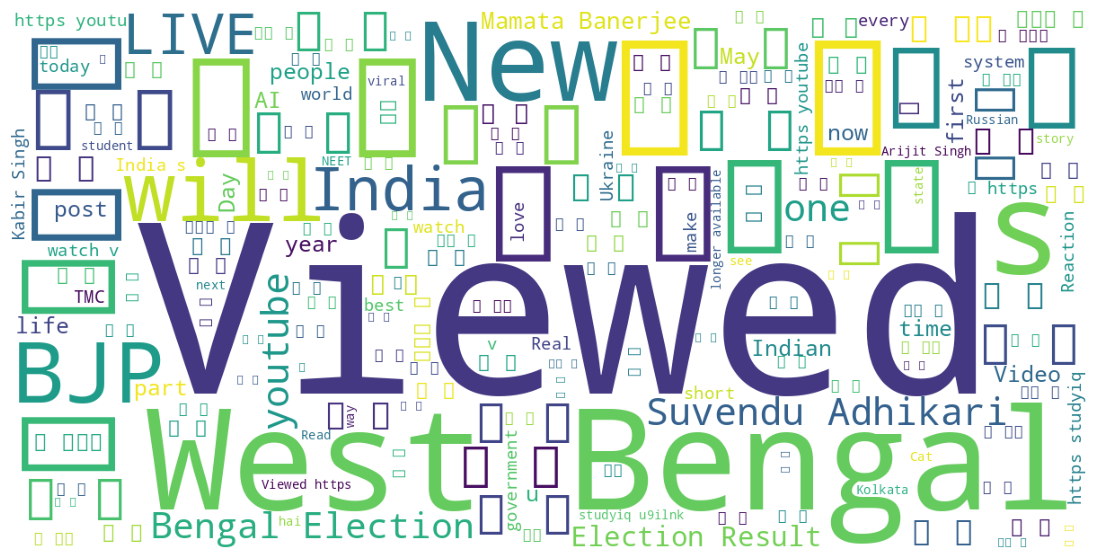

In [46]:
from wordcloud import WordCloud

text = " ".join(df["title_clean"].dropna())

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [47]:
def category(title):
    title = str(title).lower()

    if "ai" in title or "chatgpt" in title or "ml" in title:
        return "AI/ML"

    elif "history" in title or "war" in title:
        return "History"

    elif "cat" in title or "dog" in title or "kitten" in title:
        return "Animals"

    elif "politics" in title or "modi" in title or "bangladesh" in title:
        return "Politics"

    elif "project" in title or "job" in title or "resume" in title:
        return "Career"

    else:
        return "Other"

df["category"] = df["title_clean"].apply(category)

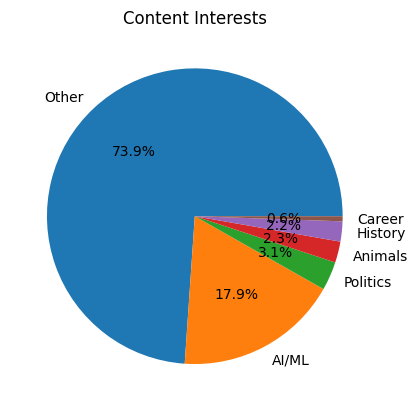

In [48]:
df["category"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Content Interests")
plt.ylabel("")
plt.show()

In [49]:
print(df["time"].min())
print(df["time"].max())

2026-05-02 06:46:38.351000+00:00
2026-05-22 07:19:09.868000+00:00


In [50]:
df["year"] = df["time"].dt.year

print(df["year"].value_counts().sort_index())

year
2026    4500
Name: count, dtype: int64


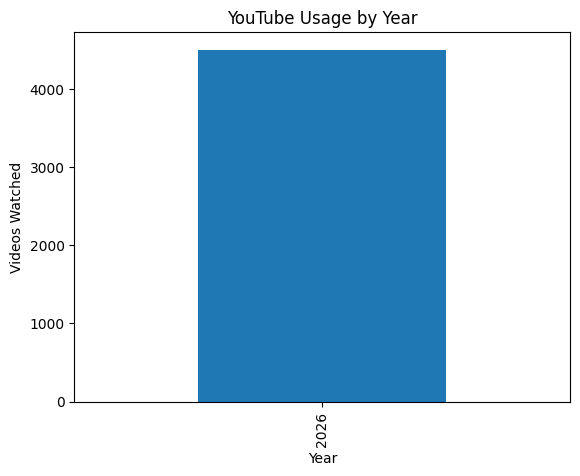

In [51]:
yearly = df["year"].value_counts().sort_index()

yearly.plot(kind="bar")

plt.title("YouTube Usage by Year")
plt.xlabel("Year")
plt.ylabel("Videos Watched")

plt.show()

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [53]:
df.head()

,title_clean,channel,time,titleUrl,hour,date,day,category,year
0,মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধান্ত মানব...,Aaj Tak Bangla,2026-05-22 07:19:09.868000+00:00,https://www.youtube.com/watch?v=__9pXNTYb3E,7,2026-05-22,Friday,Other,2026
1,😭BLURRED COPIES+SITE NOT WORKING 💔#cbse #cbsec...,Shree,2026-05-22 07:18:28.031000+00:00,https://www.youtube.com/watch?v=3kptOVnxEsY,7,2026-05-22,Friday,Other,2026
2,Bengal Makes Vande Mataram Mandatory In School...,India Today,2026-05-22 07:17:45.175000+00:00,https://www.youtube.com/watch?v=WVWICiQ_paI,7,2026-05-22,Friday,Other,2026
3,Cockroach Janta Party Anthem song CJP2026,Pawan Meghwanshi official,2026-05-22 07:17:08.216000+00:00,https://www.youtube.com/watch?v=Wvqe-lIYLOE,7,2026-05-22,Friday,Other,2026
4,It's time to set Bangladesh Fielding🤣🚩 #suvend...,Bharat Matters,2026-05-22 07:16:46.124000+00:00,https://www.youtube.com/watch?v=M6pTkLSnSJ8,7,2026-05-22,Friday,Politics,2026


In [54]:
pip install vaderSentiment textblob nrclex plotly

Note: you may need to restart the kernel to use updated packages.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from nrclex import NRCLex
import warnings
warnings.filterwarnings("ignore")

analyzer = SentimentIntensityAnalyzer()

In [56]:
def get_vader_scores(text):
    scores = analyzer.polarity_scores(str(text))
    return scores["compound"], scores["pos"], scores["neg"], scores["neu"]

df["compound"], df["positive"], df["negative"], df["neutral"] = zip(
    *df["title_clean"].apply(get_vader_scores)
)

def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["compound"].apply(label_sentiment)

print(df["sentiment"].value_counts())
print(df[["title_clean", "compound", "sentiment"]].head(10))

sentiment
Neutral     2474
Positive    1171
Negative     855
Name: count, dtype: int64
                                         title_clean  compound sentiment
0  মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধান্ত মানব...    0.0000   Neutral
1  😭BLURRED COPIES+SITE NOT WORKING 💔#cbse #cbsec...   -0.1396  Negative
2  Bengal Makes Vande Mataram Mandatory In School...    0.0772  Positive
3          Cockroach Janta Party Anthem song CJP2026    0.4019  Positive
4  It's time to set Bangladesh Fielding🤣🚩 #suvend...    0.4939  Positive
5  Samsung One UI 8.5 Stable Update - Top 10 Feat...    0.4588  Positive
6          ONE UI 8.5 Just Changed Samsung ! #shorts    0.0000   Neutral
7                This OneUI 8.5 Feature Is So Useful    0.5777  Positive
8                    Samsung OneUI 8.5 This Is Smart    0.4019  Positive
9  Your Projects Won't Get You Hired (Here's What...    0.0000   Neutral


In [57]:
def get_textblob(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df["tb_polarity"], df["tb_subjectivity"] = zip(
    *df["title_clean"].apply(get_textblob)
)

print(df[["title_clean", "tb_polarity", "tb_subjectivity"]].head(10))

                                         title_clean  tb_polarity  \
0  মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধান্ত মানব...     0.000000   
1  😭BLURRED COPIES+SITE NOT WORKING 💔#cbse #cbsec...     0.000000   
2  Bengal Makes Vande Mataram Mandatory In School...     0.000000   
3          Cockroach Janta Party Anthem song CJP2026     0.000000   
4  It's time to set Bangladesh Fielding🤣🚩 #suvend...     0.000000   
5  Samsung One UI 8.5 Stable Update - Top 10 Feat...     0.500000   
6          ONE UI 8.5 Just Changed Samsung ! #shorts     0.000000   
7                This OneUI 8.5 Feature Is So Useful     0.300000   
8                    Samsung OneUI 8.5 This Is Smart     0.214286   
9  Your Projects Won't Get You Hired (Here's What...     0.000000   

   tb_subjectivity  
0         0.000000  
1         0.000000  
2         0.100000  
3         0.000000  
4         0.000000  
5         0.500000  
6         0.000000  
7         0.000000  
8         0.642857  
9         0.000000  


In [60]:
# Run this to inspect NRCLex
from nrclex import NRCLex
test = NRCLex("this is an amazing and scary video")
print(dir(test))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lexicon__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_build_word_affect', '_compute_top_emotions', '_resolve_lexicon', 'load_raw_text', 'load_token_list']


In [62]:
test = NRCLex("this is an amazing and scary video")
test.load_raw_text("this is an amazing and scary video")
print(dir(test))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lexicon__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_build_word_affect', '_compute_top_emotions', '_resolve_lexicon', 'affect_dict', 'affect_frequencies', 'affect_list', 'load_raw_text', 'load_token_list', 'raw_emotion_scores', 'sentences', 'text', 'top_emotions', 'words']


In [64]:
import subprocess
subprocess.run(["pip", "uninstall", "nrclex", "-y"])
subprocess.run(["pip", "install", "nrclex", "--no-cache-dir"])

Found existing installation: NRCLex 4.1.0
Uninstalling NRCLex-4.1.0:
  Successfully uninstalled NRCLex-4.1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 18.7 MB/s eta 0:00:00


CompletedProcess(args=['pip', 'install', 'nrclex', '--no-cache-dir'], returncode=0)

In [66]:
# Emotion lexicon — no external dependencies needed
emotion_lexicon = {
    "joy"          : ["happy", "love", "amazing", "best", "great", "fun", "excited", "wonderful", "enjoy", "awesome", "laugh", "smile", "celebrate", "win", "beautiful"],
    "anger"        : ["angry", "worst", "hate", "terrible", "awful", "stupid", "useless", "rage", "furious", "annoying", "bad", "pathetic", "ridiculous", "disgusting"],
    "fear"         : ["scary", "fear", "horror", "dark", "danger", "threat", "panic", "terrifying", "afraid", "creepy", "nightmare", "shocking", "alarming"],
    "sadness"      : ["sad", "cry", "grief", "loss", "miss", "lonely", "depressed", "unhappy", "pain", "heartbreak", "tragedy", "unfortunate", "dying", "death"],
    "surprise"     : ["shocking", "unexpected", "unbelievable", "wow", "suddenly", "surprise", "revealed", "secret", "exposed", "mind-blowing", "twist"],
    "disgust"      : ["disgusting", "gross", "nasty", "awful", "vile", "repulsive", "sick", "horrible", "filthy", "trash"],
    "trust"        : ["honest", "reliable", "safe", "truth", "proven", "trusted", "real", "genuine", "legit", "verified", "accurate"],
    "anticipation" : ["coming", "soon", "next", "future", "upcoming", "new", "latest", "first", "finally", "waiting", "preview", "trailer", "leak"]
}

def get_emotions(text):
    text = str(text).lower()
    result = {}
    for emotion, keywords in emotion_lexicon.items():
        result[emotion] = sum(1 for word in keywords if word in text)
    return result

emotion_df = df["title_clean"].apply(get_emotions).apply(pd.Series)
df = pd.concat([df, emotion_df], axis=1)

emotion_totals = emotion_df.sum().sort_values(ascending=False)
print(emotion_totals)

anticipation    783
joy             510
trust           227
sadness         175
anger           130
fear            108
surprise         81
disgust          11
dtype: int64


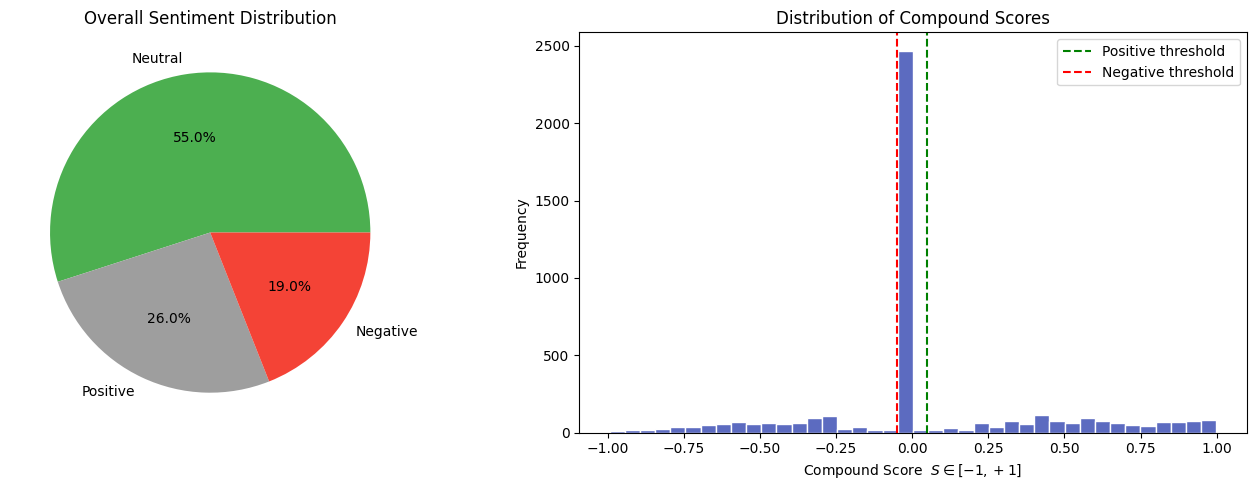

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#4CAF50", "#9E9E9E", "#F44336"],
    ax=axes[0]
)
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_ylabel("")

# Compound score histogram
axes[1].hist(df["compound"], bins=40, color="#5C6BC0", edgecolor="white")
axes[1].axvline(0.05, color="green", linestyle="--", label="Positive threshold")
axes[1].axvline(-0.05, color="red", linestyle="--", label="Negative threshold")
axes[1].set_title("Distribution of Compound Scores")
axes[1].set_xlabel("Compound Score  $S \\in [-1, +1]$")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

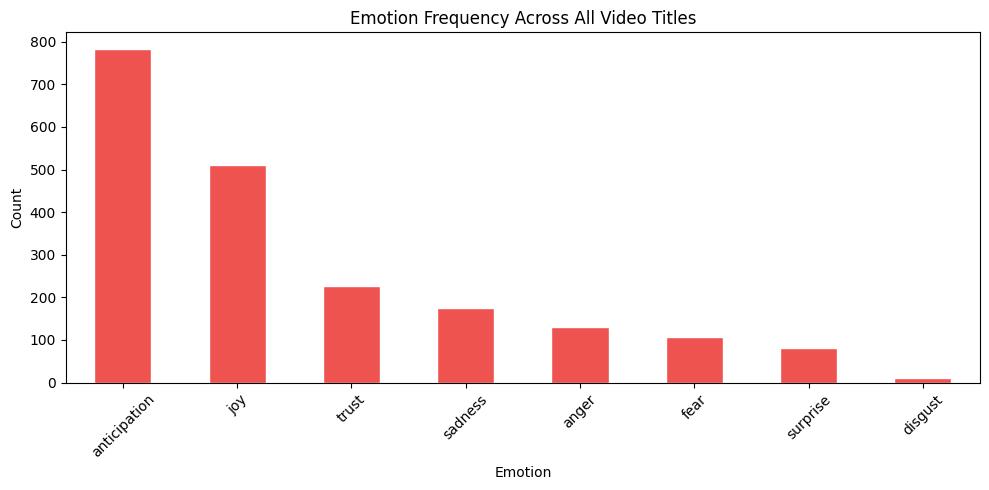

In [68]:
plt.figure(figsize=(10, 5))
emotion_totals.plot(kind="bar", color="#EF5350", edgecolor="white")
plt.title("Emotion Frequency Across All Video Titles")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

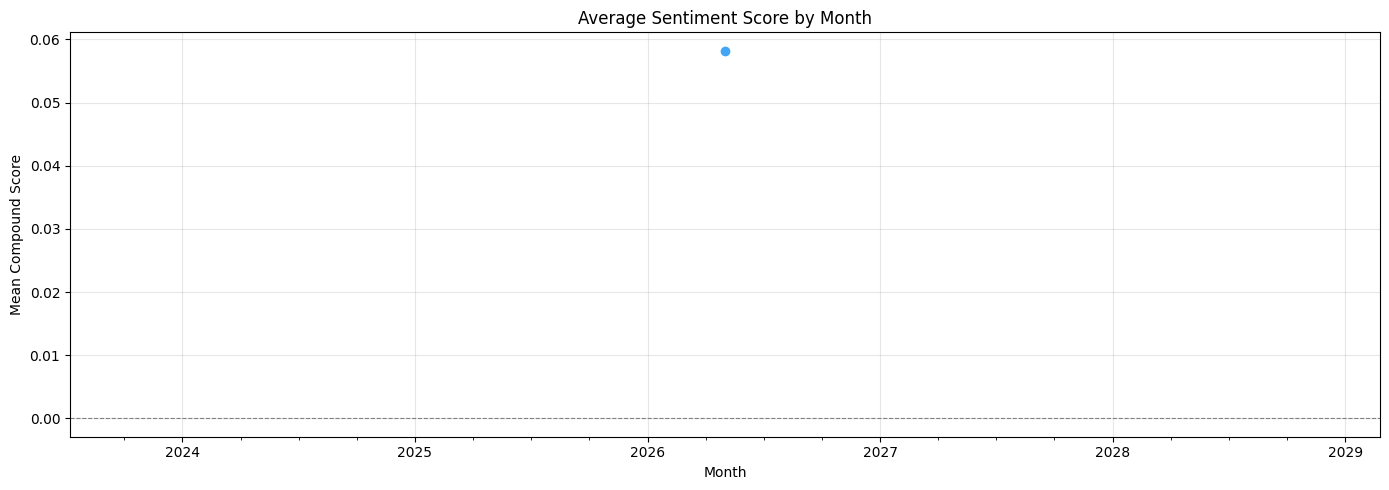

In [69]:
df["month"] = df["time"].dt.to_period("M")

monthly_sentiment = df.groupby("month")["compound"].mean()

plt.figure(figsize=(14, 5))
monthly_sentiment.plot(marker="o", color="#42A5F5")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Average Sentiment Score by Month")
plt.xlabel("Month")
plt.ylabel("Mean Compound Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

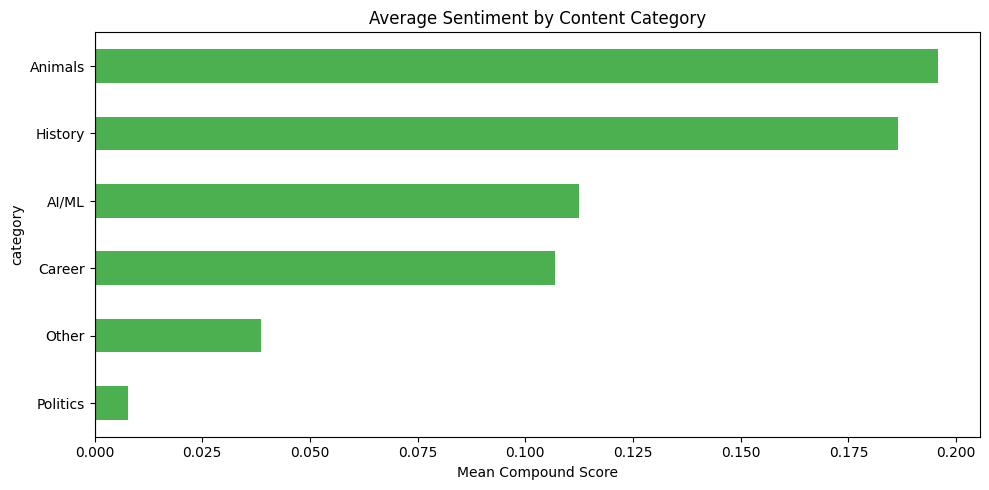

In [70]:
cat_sentiment = df.groupby("category")["compound"].mean().sort_values()

plt.figure(figsize=(10, 5))
colors = ["#F44336" if x < 0 else "#4CAF50" for x in cat_sentiment]
cat_sentiment.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Average Sentiment by Content Category")
plt.xlabel("Mean Compound Score")
plt.tight_layout()
plt.show()

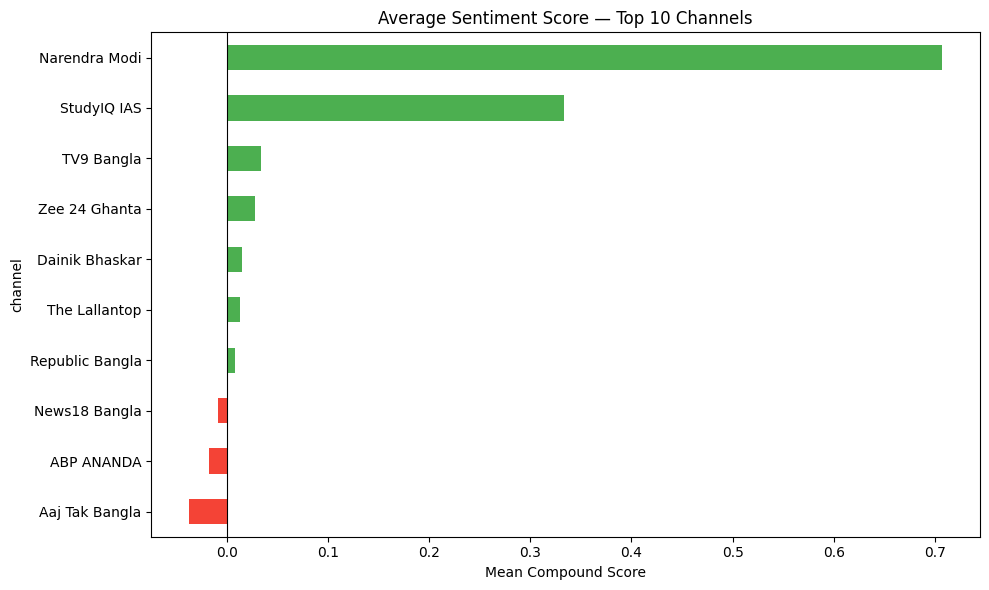

In [71]:
top_10_channels = df["channel"].value_counts().head(10).index

channel_sentiment = (
    df[df["channel"].isin(top_10_channels)]
    .groupby("channel")["compound"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
colors = ["#F44336" if x < 0 else "#4CAF50" for x in channel_sentiment]
channel_sentiment.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Average Sentiment Score — Top 10 Channels")
plt.xlabel("Mean Compound Score")
plt.tight_layout()
plt.show()

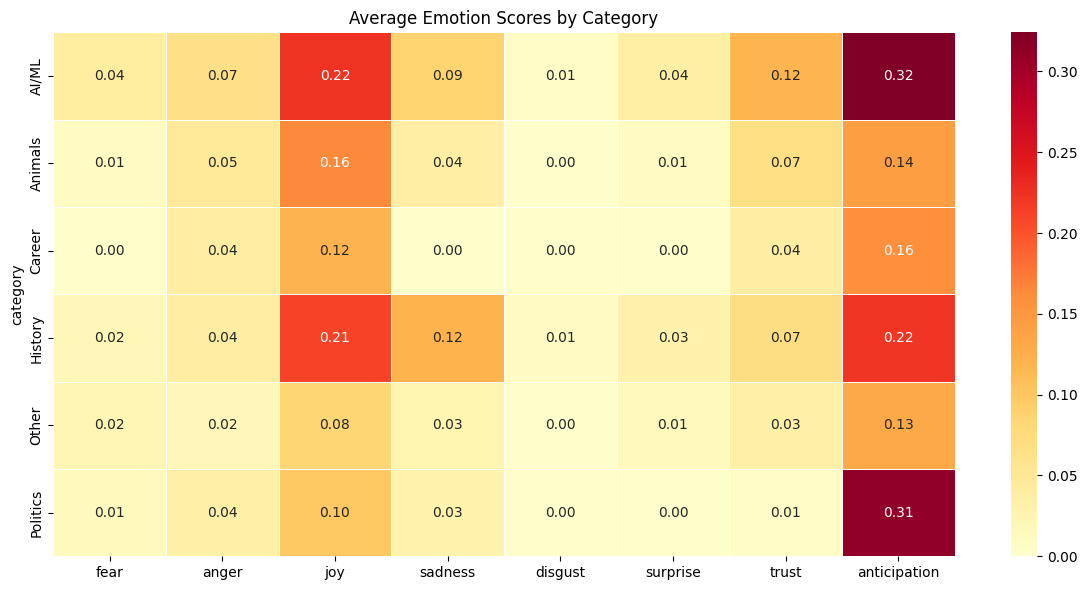

In [72]:
emotions = ["fear", "anger", "joy", "sadness", "disgust", "surprise", "trust", "anticipation"]

emotion_by_cat = df.groupby("category")[emotions].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(
    emotion_by_cat,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Average Emotion Scores by Category")
plt.tight_layout()
plt.show()

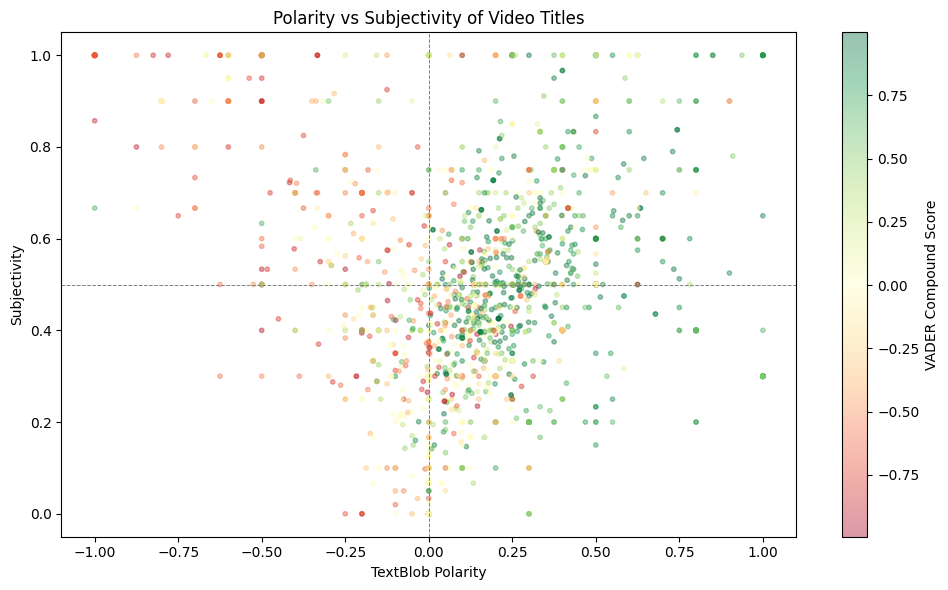

In [73]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df["tb_polarity"],
    df["tb_subjectivity"],
    c=df["compound"],
    cmap="RdYlGn",
    alpha=0.4,
    s=10
)
plt.colorbar(scatter, label="VADER Compound Score")
plt.xlabel("TextBlob Polarity")
plt.ylabel("Subjectivity")
plt.title("Polarity vs Subjectivity of Video Titles")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.7)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()

In [74]:
print("=" * 45)
print("Sentiment Analysis Summary")
print("=" * 45)
print(f"Total videos analyzed : {len(df)}")
print(f"Positive              : {(df['sentiment'] == 'Positive').sum()}")
print(f"Neutral               : {(df['sentiment'] == 'Neutral').sum()}")
print(f"Negative              : {(df['sentiment'] == 'Negative').sum()}")
print(f"Mean compound score   : {df['compound'].mean():.4f}")
print(f"Mean subjectivity     : {df['tb_subjectivity'].mean():.4f}")
print(f"Most emotional cat    : {df.groupby('category')['compound'].mean().idxmax()}")
print(f"Least emotional cat   : {df.groupby('category')['compound'].mean().idxmin()}")
print("=" * 45)

Sentiment Analysis Summary
Total videos analyzed : 4500
Positive              : 1171
Neutral               : 2474
Negative              : 855
Mean compound score   : 0.0582
Mean subjectivity     : 0.2365
Most emotional cat    : Animals
Least emotional cat   : Politics
